In [46]:
# =========================
# LOAD TRAINED MODEL (COLON)
# =========================
import torch
import torch.nn as nn
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Recreate SAME model architecture
weights = EfficientNet_B0_Weights.DEFAULT
model = efficientnet_b0(weights=weights)

# 🔥 IMPORTANT: match training setup
for param in model.features[:2].parameters():   # ← use same as your final training
    param.requires_grad = False

for param in model.features[2:].parameters():
    param.requires_grad = True

# Classifier (UPDATED FOR COLON)
in_features = model.classifier[1].in_features

model.classifier = nn.Sequential(
    nn.Linear(in_features, 256),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(256, 2)   # ✅ 2 classes (colon)
)

# Load trained weights
model.load_state_dict(torch.load("best_model.pth", map_location=device))

model = model.to(device)
model.eval()

print("✅ Colon model loaded successfully")

C:\Users\Bramha\AppData\Local\Temp\ipykernel_16576\1560818733.py:32: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_model.pth", map_loc

✅ Colon model loaded successfully


In [6]:
target_layer = model.features[-1]

In [7]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        
        self.gradients = None
        self.activations = None

        # Hooks
        self.target_layer.register_forward_hook(self.forward_hook)
        self.target_layer.register_full_backward_hook(self.backward_hook)

    def forward_hook(self, module, input, output):
        self.activations = output.detach()

    def backward_hook(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, input_tensor, class_idx=None):
        output = self.model(input_tensor)

        # Get predicted class
        if class_idx is None:
            class_idx = torch.argmax(output, dim=1).item()

        self.model.zero_grad()
        output[0, class_idx].backward()

        gradients = self.gradients[0]
        activations = self.activations[0]

        # Global average pooling
        weights = torch.mean(gradients, dim=(1, 2))

        # Weighted combination
        cam = torch.zeros(activations.shape[1:], dtype=torch.float32).to(activations.device)

        for i, w in enumerate(weights):
            cam += w * activations[i]

        cam = torch.relu(cam)

        # Normalize
        cam -= cam.min()
        cam /= (cam.max() + 1e-8)

        return cam.cpu().numpy()

In [8]:
import random
import os
from PIL import Image

def get_random_images(root_dir, classes, n_images):
    all_images = []

    for cls in classes:
        class_path = os.path.join(root_dir, cls)

        images = [
            os.path.join(class_path, img)
            for img in os.listdir(class_path)
            if img.lower().endswith(('.png', '.jpg', '.jpeg'))
        ]

        all_images.extend(images)

    # Safety check
    if n_images > len(all_images):
        raise ValueError(f"Requested {n_images}, but only {len(all_images)} available")

    selected = random.sample(all_images, n_images)
    return selected

In [9]:
# =========================
# PREPROCESS FUNCTION
# =========================

import torchvision.transforms as transforms
IMG_SIZE = 224
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

def preprocess_image(path):
    image = Image.open(path).convert("RGB")
    tensor = transform(image).unsqueeze(0)
    return image, tensor.to(device)

In [13]:
class_names = ['colon_aca', 'colon_n']
test_dir = r"F:\CV Project\LC25000\lung_colon_image_set\Test Set"

image_paths = get_random_images(test_dir, class_names, n_images=5)

print(image_paths)

['F:\\CV Project\\LC25000\\lung_colon_image_set\\Test Set\\colon_aca\\colonca4633.jpeg', 'F:\\CV Project\\LC25000\\lung_colon_image_set\\Test Set\\colon_n\\colonn4053.jpeg', 'F:\\CV Project\\LC25000\\lung_colon_image_set\\Test Set\\colon_aca\\colonca4500.jpeg', 'F:\\CV Project\\LC25000\\lung_colon_image_set\\Test Set\\colon_aca\\colonca4323.jpeg', 'F:\\CV Project\\LC25000\\lung_colon_image_set\\Test Set\\colon_n\\colonn4117.jpeg']


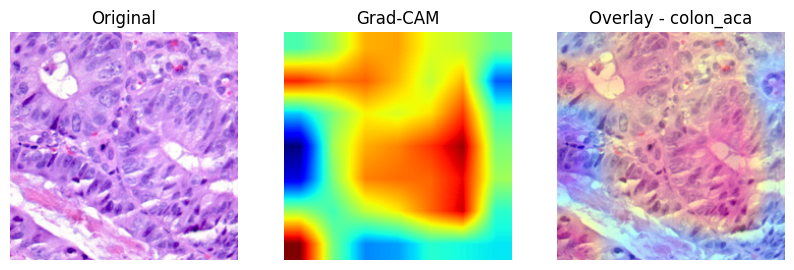

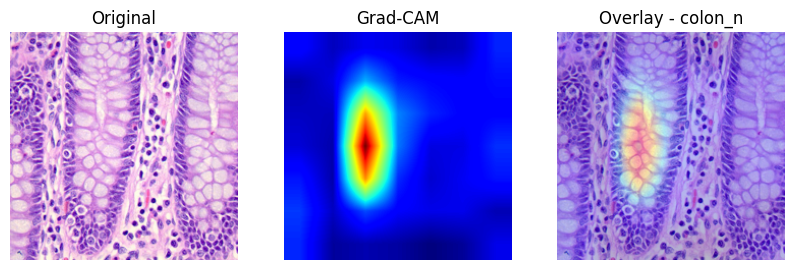

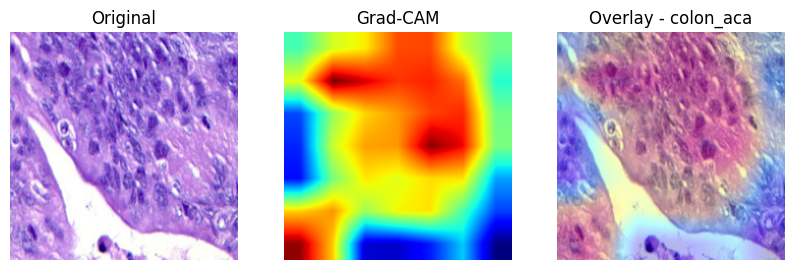

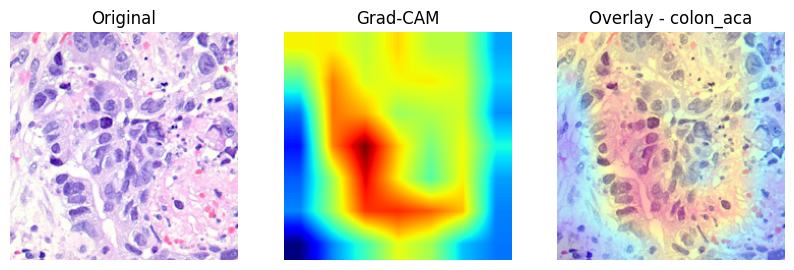

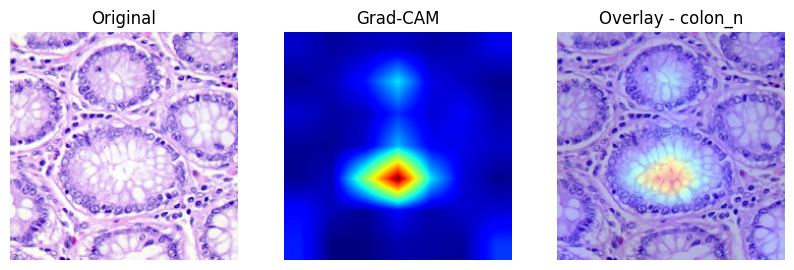

In [15]:
import matplotlib.pyplot as plt
import cv2
import numpy as np
import torch

gradcam = GradCAM(model, target_layer)

for path in image_paths:
    original_image, input_tensor = preprocess_image(path)

    cam = gradcam.generate(input_tensor)

    # Resize CAM
    cam = cv2.resize(cam, (IMG_SIZE, IMG_SIZE))

    # Heatmap
    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)  # ✅ FIX
    heatmap = np.float32(heatmap) / 255

    original_np = np.array(original_image.resize((IMG_SIZE, IMG_SIZE))) / 255

    # Overlay
    overlay = heatmap * 0.4 + original_np
    overlay = overlay / (np.max(overlay) + 1e-8)  # ✅ FIX

    # Prediction
    with torch.no_grad():  # ✅ FIX
        output = model(input_tensor)
        pred_class = torch.argmax(output, dim=1).item()

    plt.figure(figsize=(10,4))

    plt.subplot(1,3,1)
    plt.imshow(original_np)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.imshow(cam, cmap='jet')
    plt.title("Grad-CAM")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.imshow(overlay)
    plt.title(f"Overlay - {class_names[pred_class]}")
    plt.axis("off")

    plt.show()

In [16]:
# =========================
# LOAD MODEL (COLON)
# =========================
import torch
import torch.nn as nn
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

weights = EfficientNet_B0_Weights.DEFAULT
model = efficientnet_b0(weights=weights)

# 🔥 Match EXACT training setup
for param in model.features[:2].parameters():   # <-- adjust if needed
    param.requires_grad = False

for param in model.features[2:].parameters():
    param.requires_grad = True

in_features = model.classifier[1].in_features

model.classifier = nn.Sequential(
    nn.Linear(in_features, 256),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(256, 2)   # ✅ FIXED (2 classes)
)

# Load weights
model.load_state_dict(torch.load("best_model.pth", map_location=device))

model = model.to(device)
model.eval()

print("✅ Colon Model Loaded")

C:\Users\Bramha\AppData\Local\Temp\ipykernel_16576\1843508744.py:28: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_model.pth", map_loc

✅ Colon Model Loaded


In [17]:
# =========================
# BALANCED RANDOM SAMPLING (COLON)
# =========================
import os
import random

test_dir = r"F:\CV Project\LC25000\lung_colon_image_set\Test Set"

# ✅ Correct classes
class_names = ['colon_aca', 'colon_n']

image_paths = []
labels = []

total_samples = 50
samples_per_class = total_samples // len(class_names)  # 25 each

for idx, cls in enumerate(class_names):
    class_path = os.path.join(test_dir, cls)

    all_imgs = [
        img for img in os.listdir(class_path)
        if img.lower().endswith(('.jpg', '.jpeg', '.png'))
    ]

    selected_imgs = random.sample(all_imgs, samples_per_class)

    for img in selected_imgs:
        image_paths.append(os.path.join(class_path, img))
        labels.append(idx)

# Shuffle
combined = list(zip(image_paths, labels))
random.shuffle(combined)
image_paths, labels = zip(*combined)

print("Total selected:", len(image_paths))
print("Class distribution:", {cls: labels.count(i) for i, cls in enumerate(class_names)})

Total selected: 50
Class distribution: {'colon_aca': 25, 'colon_n': 25}


In [18]:
# =========================
# TRANSFORM
# =========================
import torchvision.transforms as transforms
from PIL import Image

IMG_SIZE = 224

transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# =========================
# NOISE FUNCTION (CORRECT)
# =========================
def add_noise(tensor, noise_level=0.1):
    noise = torch.randn_like(tensor) * noise_level
    return tensor + noise

In [19]:
import numpy as np

y_true = []
y_pred_original = []
y_pred_noisy = []

flip_count = 0

for path, label in zip(image_paths, labels):
    image = Image.open(path).convert("RGB")
    input_tensor = transform(image).unsqueeze(0).to(device)

    # Original prediction
    with torch.no_grad():
        output = model(input_tensor)
        pred_orig = torch.argmax(output, dim=1).item()

    # Noisy prediction
    noisy_input = add_noise(input_tensor.clone(), noise_level=0.1)

    with torch.no_grad():
        output_noisy = model(noisy_input)
        pred_noisy = torch.argmax(output_noisy, dim=1).item()

    # Store
    y_true.append(label)
    y_pred_original.append(pred_orig)
    y_pred_noisy.append(pred_noisy)

    if pred_orig != pred_noisy:
        flip_count += 1

In [20]:
# =========================
# EVALUATION (COLON)
# =========================
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("\n===== ORIGINAL PERFORMANCE =====")
print("Accuracy:", accuracy_score(y_true, y_pred_original))
print(classification_report(
    y_true, 
    y_pred_original, 
    labels=[0,1], 
    target_names=class_names
))

print("\n===== NOISY PERFORMANCE =====")
print("Accuracy:", accuracy_score(y_true, y_pred_noisy))
print(classification_report(
    y_true, 
    y_pred_noisy, 
    labels=[0,1], 
    target_names=class_names
))

print("\n===== STABILITY ANALYSIS =====")
print("Total Samples:", len(y_true))
print("Prediction Flips:", flip_count)
print("Flip %:", (flip_count / len(y_true)) * 100)


===== ORIGINAL PERFORMANCE =====
Accuracy: 1.0
              precision    recall  f1-score   support

   colon_aca       1.00      1.00      1.00        25
     colon_n       1.00      1.00      1.00        25

    accuracy                           1.00        50
   macro avg       1.00      1.00      1.00        50
weighted avg       1.00      1.00      1.00        50


===== NOISY PERFORMANCE =====
Accuracy: 1.0
              precision    recall  f1-score   support

   colon_aca       1.00      1.00      1.00        25
     colon_n       1.00      1.00      1.00        25

    accuracy                           1.00        50
   macro avg       1.00      1.00      1.00        50
weighted avg       1.00      1.00      1.00        50


===== STABILITY ANALYSIS =====
Total Samples: 50
Prediction Flips: 0
Flip %: 0.0


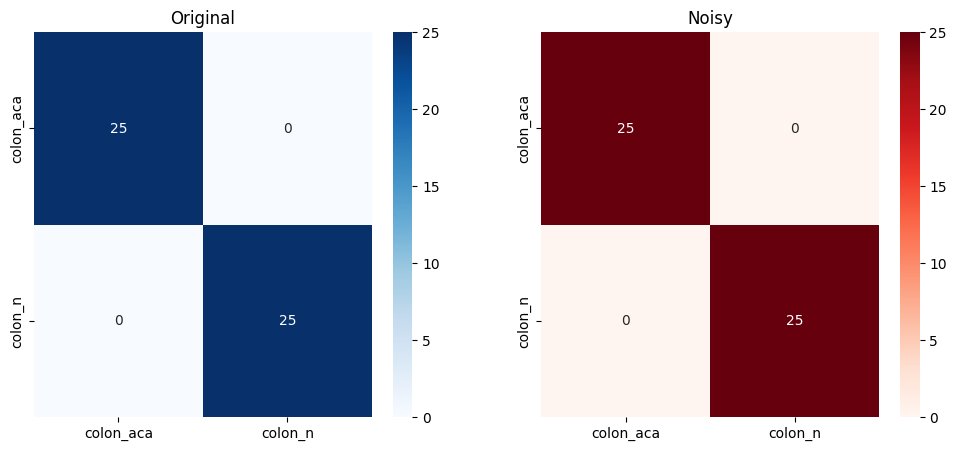

In [21]:
# =========================
# CONFUSION MATRICES (COLON)
# =========================
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm_orig = confusion_matrix(y_true, y_pred_original, labels=[0,1])
cm_noisy = confusion_matrix(y_true, y_pred_noisy, labels=[0,1])

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.heatmap(cm_orig, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title("Original")

plt.subplot(1,2,2)
sns.heatmap(cm_noisy, annot=True, fmt='d', cmap='Reds',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title("Noisy")

plt.show()

-------------------------------OOD CHECK------------------------------------------